In [22]:
#classical implementation
def classical_priority_mux(s3, s2, s1, s0):

    if s3 == 1:
        return "Fire Detected (High Priority)"
    elif s2 == 1:
        return "Gas Leakage"
    elif s1 == 1:
        return "Intrusion"
    elif s0 == 1:
        return "Medical Emergency (Low Priority)"
    else:
        return "No Signal"


print(f"Classical Output: {classical_priority_mux(1, 0, 1, 0)}")

Classical Output: Fire Detected (High Priority)


In [23]:
# quantum implementation
!pip install qiskit qiskit-aer

In [24]:
%matplotlib inline

In [25]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
from IPython.display import display

# Qubits:
# q0 = Medical (s0)
# q1 = Intruder (s1)
# q2 = Gas (s2)
# q3 = Fire (s3)
# q4 = Output (mux output)


qc = QuantumCircuit(5, 1) # 5 qubits, 1 classical bit for measurement of q4

qc.h([0,1,2,3])

qc.barrier()

# ---- PRIORITY LOGIC ----

# Fire (q3) → output (q4) = 1
qc.cx(3, 4)

# Gas (q2) → only if Fire (q3) = 0
qc.x(3)
qc.ccx(3, 2, 4)
qc.x(3)

# Intruder (q1) → only if Fire=0 AND Gas=0
qc.x(3)
qc.x(2)
qc.mcx([3,2,1], 4)
qc.x(2)
qc.x(3)

# Medical (q0) → only if all higher = 0
qc.x([3,2,1])
qc.mcx([3,2,1,0], 4)
qc.x([3,2,1])

qc.barrier()


qc.measure(4, 0)


backend = Aer.get_backend('qasm_simulator')
job = backend.run(qc, shots=1024)
result = job.result()
counts = result.get_counts(qc)

# ---- STATEVECTOR ----

qc_for_sv = QuantumCircuit(5)


qc_for_sv.h([0,1,2,3])
qc_for_sv.barrier()
qc_for_sv.cx(3, 4)
qc_for_sv.x(3)
qc_for_sv.ccx(3, 2, 4)
qc_for_sv.x(3)
qc_for_sv.x(3)
qc_for_sv.x(2)
qc_for_sv.mcx([3,2,1], 4)
qc_for_sv.x(2)
qc_for_sv.x(3)
qc_for_sv.x([3,2,1])
qc_for_sv.mcx([3,2,1,0], 4)
qc_for_sv.x([3,2,1])
qc_for_sv.barrier()

sv = Statevector.from_instruction(qc_for_sv)
print(sv)
print(f"Counts for output qubit q4 (0 or 1): {counts}")

Statevector([ 2.50000000e-01+2.05186023e-17j,
             -3.27706213e-17+3.89551279e-17j,
              6.48169014e-18+1.13007874e-17j,
             -1.55255175e-17+1.21426164e-17j,
              1.79784260e-17-5.20372250e-18j,
             -1.64772974e-18+4.58940218e-17j,
              3.42372658e-17-6.88827634e-18j,
              1.46111100e-17+3.46429561e-17j,
             -1.55255175e-17-2.32953853e-18j,
             -2.12738855e-17+3.60809439e-17j,
              3.42372658e-17-1.33331424e-17j,
             -1.31444656e-17+2.96351820e-17j,
              6.48169014e-18-2.34949172e-17j,
             -1.64772974e-18+8.92063131e-18j,
             -1.88928335e-17-3.98232345e-17j,
             -1.79065695e-17+1.91998772e-17j,
              2.03594779e-17-1.87337092e-17j,
              2.50000000e-01+4.87682058e-17j,
              2.50000000e-01-8.32536832e-18j,
              2.50000000e-01-2.71096951e-17j,
              2.50000000e-01+2.42355111e-17j,
              2.50000000e-01+4.589

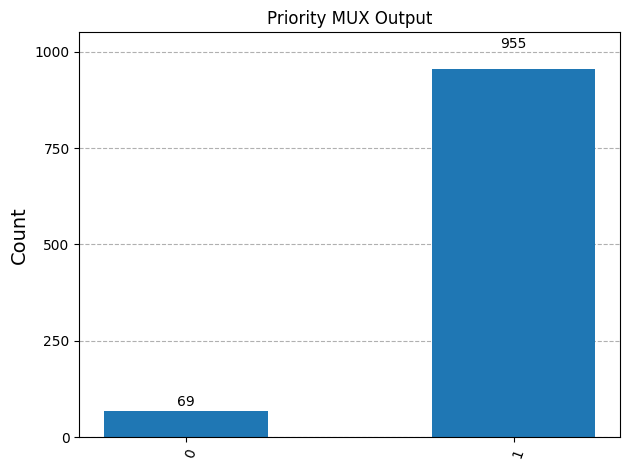

In [26]:
from qiskit.visualization import plot_histogram
from IPython.display import display

fig = plot_histogram(counts, title="Priority MUX Output")
display(fig)

In [27]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer

backend = Aer.get_backend('qasm_simulator')

def run_case(s0, s1, s2, s3):
    qc = QuantumCircuit(5,1)


    if s0: qc.x(0)
    if s1: qc.x(1)
    if s2: qc.x(2)
    if s3: qc.x(3)


    qc.cx(3, 4)

    qc.x(3)
    qc.ccx(3, 2, 4)
    qc.x(3)

    qc.x(3)
    qc.x(2)
    qc.mcx([3,2,1], 4)
    qc.x(2)
    qc.x(3)

    qc.x([3,2,1])
    qc.mcx([3,2,1,0], 4)
    qc.x([3,2,1])

    qc.measure(4,0)

    result = backend.run(qc, shots=1).result()
    return list(result.get_counts().keys())[0]

print("S3 S2 S1 S0 | Output")
print("--------------------")

for i in range(16):
    s0 = (i>>0)&1
    s1 = (i>>1)&1
    s2 = (i>>2)&1
    s3 = (i>>3)&1

    out = run_case(s0,s1,s2,s3)
    print(f"{s3}  {s2}  {s1}  {s0}  |   {out}")

S3 S2 S1 S0 | Output
--------------------
0  0  0  0  |   0
0  0  0  1  |   1
0  0  1  0  |   1
0  0  1  1  |   1
0  1  0  0  |   1
0  1  0  1  |   1
0  1  1  0  |   1
0  1  1  1  |   1
1  0  0  0  |   1
1  0  0  1  |   1
1  0  1  0  |   1
1  0  1  1  |   1
1  1  0  0  |   1
1  1  0  1  |   1
1  1  1  0  |   1
1  1  1  1  |   1


In [28]:
# Calculate and display the percentage of correctness
total_shots = 1024
observed_zeros = counts.get('0', 0)
observed_ones = counts.get('1', 0)

# Ideal probabilistic distribution for a 4-input MUX in superposition
# 15 out of 16 input states should result in a '1' output
# 1 out of 16 input states should result in a '0' output (only for 0000 input)
expected_zeros = (1/16) * total_shots
expected_ones = (15/16) * total_shots

# Calculate accuracy based on deviation from expected counts
deviation_zeros = abs(observed_zeros - expected_zeros)
deviation_ones = abs(observed_ones - expected_ones)

total_deviation = deviation_zeros + deviation_ones
accuracy = ((total_shots - total_deviation) / total_shots) * 100

print(f"Total Shots: {total_shots}")
print(f"Observed '0' Counts: {observed_zeros} (Expected: {expected_zeros})")
print(f"Observed '1' Counts: {observed_ones} (Expected: {expected_ones})")
print(f"Deviation for '0': {deviation_zeros}")
print(f"Deviation for '1': {deviation_ones}")
print(f"Total Deviation from Ideal: {total_deviation}")
print(f"Accuracy of Probabilistic Output: {accuracy:.2f}%")

print("\nNote: The `run_case` function in a previous cell (`bksudE0gr9ia`) deterministically verifies the classical logic of your quantum circuit for each specific input combination, confirming its functional correctness.")

Total Shots: 1024
Observed '0' Counts: 69 (Expected: 64.0)
Observed '1' Counts: 955 (Expected: 960.0)
Deviation for '0': 5.0
Deviation for '1': 5.0
Total Deviation from Ideal: 10.0
Accuracy of Probabilistic Output: 99.02%

Note: The `run_case` function in a previous cell (`bksudE0gr9ia`) deterministically verifies the classical logic of your quantum circuit for each specific input combination, confirming its functional correctness.
